# House Price Prediction using Linear Regression

## AIM
To build and evaluate a Linear Regression model using the California Housing Dataset.

## Objective
- Load and explore the dataset
- Perform data preprocessing
- Train a Linear Regression model
- Evaluate model performance using MAE, RMSE and R² score
- Visualize the results

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Step 1: Load California Housing Dataset

In [2]:
# Load Dataset

housing = fetch_california_housing(as_frame=True)

df = pd.concat(
    [housing.data,
     housing.target.rename("MedHouseVal")],
    axis=1
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 2: Dataset Information
Checking dataset structure and data types.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## Step 3: Statistical Summary

In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Step 4: Checking Missing Values

In [5]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### Observation

No missing values are present in the dataset.

## Step 5: Distribution of House Prices

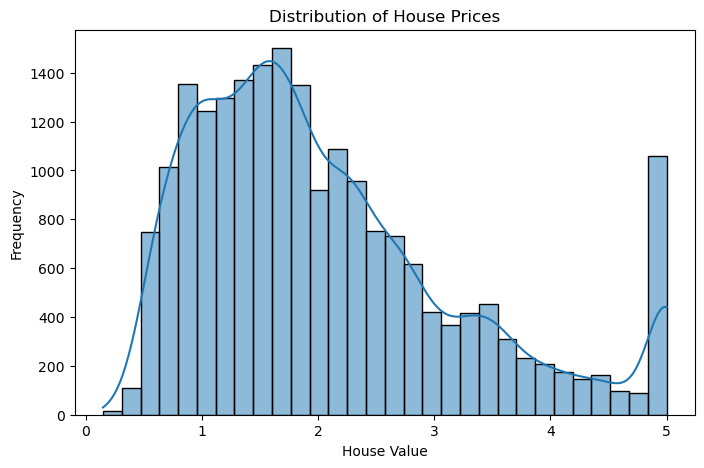

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(df['MedHouseVal'],
             bins=30,
             kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Value")
plt.ylabel("Frequency")

plt.show()

### Observation

Most house prices are concentrated in the lower to medium range.

## Step 6: Correlation Analysis

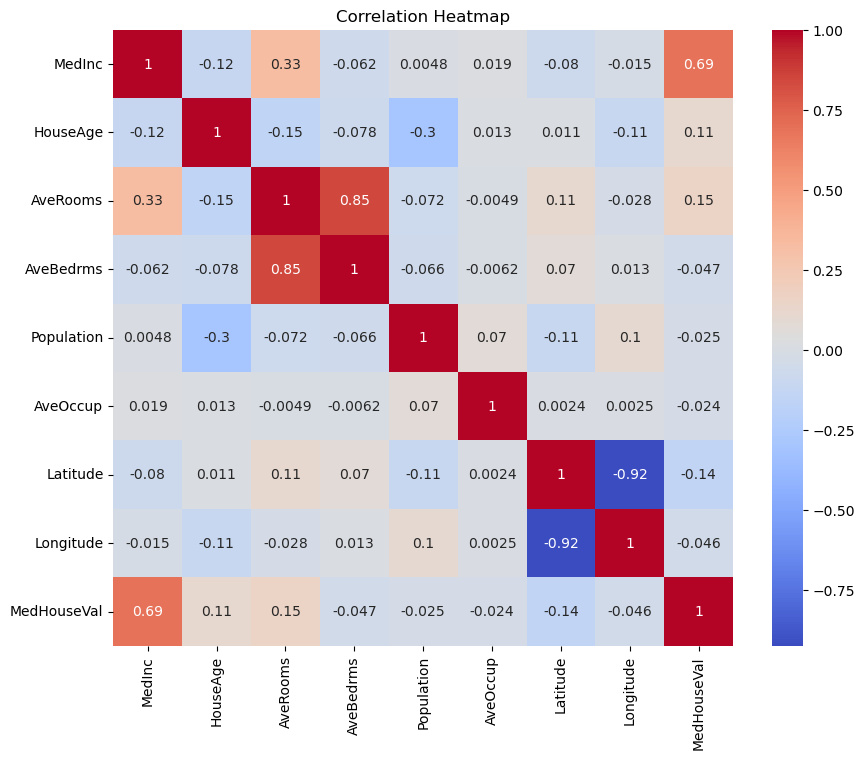

In [7]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Observation

Median Income (MedInc) shows the strongest positive correlation with house prices.

## Step 7: Income vs House Price

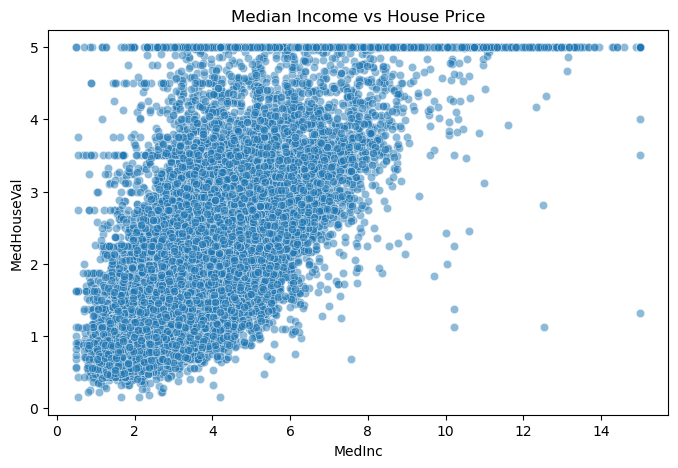

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='MedInc',
    y='MedHouseVal',
    data=df,
    alpha=0.5
)

plt.title("Median Income vs House Price")

plt.show()

### Observation

Higher income areas generally have higher house prices.

## Step 8: Splitting Dataset into Training and Testing Sets

In [10]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


## Step 9: Training Linear Regression Model

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


## Step 10: Making Predictions

In [12]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


## Step 11: Model Evaluation

In [13]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae,3))
print("Root Mean Squared Error (RMSE):", round(rmse,3))
print("R² Score:", round(r2,3))

Mean Absolute Error (MAE): 0.533
Root Mean Squared Error (RMSE): 0.746
R² Score: 0.576


### Evaluation Metrics

- MAE measures average prediction error.
- RMSE penalizes larger errors.
- R² Score shows how well the model explains the variance in data.

## Step 12: Actual vs Predicted Values

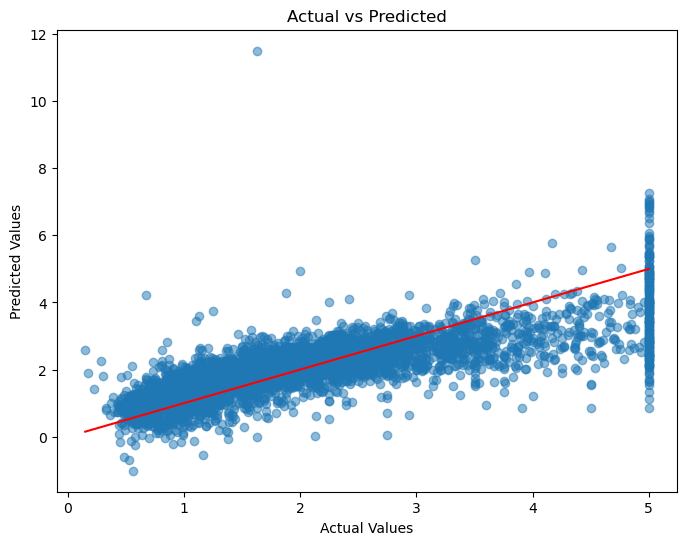

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

### Observation

Points close to the red line indicate accurate predictions.

## Step 13: Residual Analysis

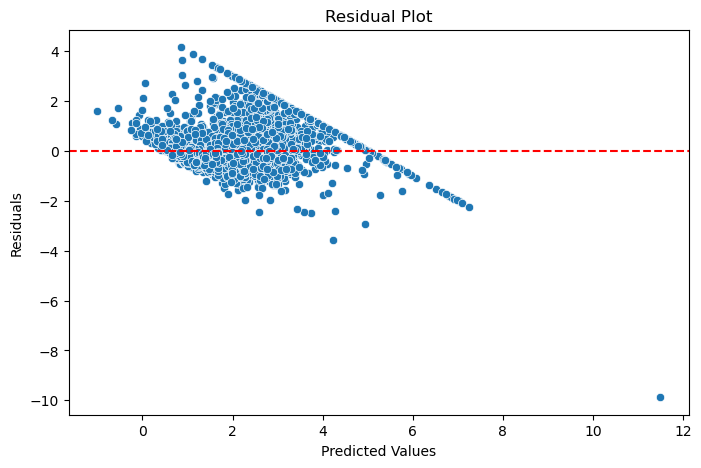

In [15]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Observation

Residuals are distributed around zero, indicating reasonable model performance.

## Step 14: Feature Importance using Coefficients

In [16]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance.sort_values(
    by='Coefficient',
    ascending=False,
    inplace=True
)

importance

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


## Step 15: Save the Trained Model

In [17]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

In this project, a Linear Regression model was developed using the California Housing Dataset.

Key Findings:

1. The dataset contained no missing values.
2. Median Income (MedInc) showed the strongest positive correlation with house prices.
3. The Linear Regression model was successfully trained and evaluated.
4. The model achieved satisfactory performance based on MAE, RMSE, and R² score.
5. Actual vs Predicted and Residual plots were used to analyze model behavior.

Future Improvements:

- Use Random Forest Regressor
- Use Gradient Boosting Regressor
- Perform Feature Engineering
- Apply Hyperparameter Tuning

The project successfully demonstrates the complete Machine Learning workflow from data loading to model evaluation.